# Experiment with Synthetic Data
Here we experiment with sythetic data and different similarity metrics to test. We use sythetic data where the similarity trend is known due to the controlled structure. 

In [ ]:
import json

import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import datetime

from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

from synthetic_datasets.base_dataset import DatasetConfig, BaseDataset, TransformConfig
from synthetic_datasets import init_dataset, get_transform_config

from manifold_repsim.experiments.legacy import get_data_param_sweep_values, run_param_sweep, plot_param_sweep, run_metric_comparison_across_data_param


# experiment parameters
sim_params = {
    "sim_name": "small_s",  # name of the experiment, used for saving results
    "dataset_type": "s_curve",  # "gaussian_cluster", "permuted_gaussian_clusters", "s_curve", "rings", "s_clusters", "ellipsoid"
    "date time": datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"),
    "n_points": 1000,
    "sigma": 1.0,
    "noise_scale": 0.01,
    "seed": 42, 
    "dim": 2,
    "n_clusters": 5,  # shared by base and current permuted Gaussian mixtures
    "balanced": False,  # False gives every cluster a distinct positive number of points
    "center_sampling": "hypersphere",  # "hypersphere", "uniform_grid", or "nonuniform_grid"
    "permuted_data_param": "n_permute",  # "n_permute" or "cluster_mixing_probability"
    "metric_param_sweep_len": 40, # number of points in the hyperparameter sweep for the metric
    "metric_sweep_ranges": {
        "cka_rbf": {"min": 0.1, "max": 3.0},
        "rbf_rwka_diffusion_time": {"min": 0.01, "max": 1000.0},
        "rbf_rwka_symmetric": {"min": 0.1, "max": 3.0},
    },
    "data_param_sweep_len": 20, # number of points in the data generation parameter sweep 
    "radius_type": "median",  # "median" or "mean"
    "visualization_method": "pca",  # "pca" or "kpca" or "tsne"
    "clusters_type": "closest",  # "closest" or "random"
    "auc_integration_method": "average",  # "trapezoidal" or "average"
    "logscale": True,  # whether to use logscale for the hyperparameter sweep
    "cutoff_threshold": 0.15,  # change from inf_score in precentile of total variation to cutoff global section in AUC calculation 
}
base_transform_params = {
    "n_permute": 0,
    "cluster_mixing_probability": 0.0,
    "center_sampling": sim_params["center_sampling"],
    "n_clusters": 5,
    "n_rings": 7,
    "sigma": sim_params["sigma"],
    "seed": sim_params["seed"],
    "dim": sim_params["dim"],
    "radius_type": sim_params["radius_type"],
    "clustering_type": sim_params["clusters_type"],
    "t": 0.5,
    "noise_scale": 0.1,
    "noise_distribution": "gaussian",  # "gaussian", "uniform", or "student_t"
    "student_t_df": 3.0,
    "cluster_noise_scales": None,  # or one standard-deviation scale per cluster
    "axis_scale": 0.2,
}

current_transform_params = {
    "n_permute": 3,
    "cluster_mixing_probability": 0.25,
    "center_sampling": "uniform_grid",  # independently choose the transformed cluster-center layout
    "n_clusters": 7,
    "n_rings": 5,
    "sigma": sim_params["sigma"],
    "seed": sim_params["seed"] + (sim_params["dataset_type"] == "permuted_gaussian_clusters"),
    "dim": sim_params["dim"],
    "radius_type": sim_params["radius_type"],
    "clustering_type": sim_params["clusters_type"],
    # "clustering_type": 'random',
    "t": 0.6,
    "noise_scale": 0.1,
    "noise_distribution": "gaussian",  # "gaussian", "uniform", or "student_t"
    "student_t_df": 3.0,
    "cluster_noise_scales": None,  # or one standard-deviation scale per cluster
    "axis_scale": 0.3,
}

figures_path = f"figures/synthetic_experiment/{sim_params['sim_name']}/{sim_params['dataset_type']}_{sim_params['clusters_type']}"
os.makedirs(figures_path, exist_ok=True)


# save sim_params to JSON
sim_params["base_transform_params"] = base_transform_params
sim_params["current_transform_params"] = current_transform_params

dataset: BaseDataset = init_dataset(sim_params)
base_transform_config: TransformConfig = get_transform_config(transform_params=base_transform_params, dataset=dataset)

with open(f"{figures_path}/sim_params.json", "w") as f:
    json.dump(sim_params, f, indent=4)


In [2]:
def plot_data(dataset: BaseDataset, title="Data", ax=None, visualization_method="pca", base_data=False):
    if base_data:
        data = dataset.get_base_numpy()
    else:
        data = dataset.get_current_numpy()
    plot_labels = dataset.plot_labels
    dim = data.shape[1]
    if dim == 2:
        plot_data = data
    else:
        # For higher dimensions, use the specified visualization method
        if visualization_method == "pca":
            pca = PCA(n_components=2)
            plot_data = pca.fit_transform(data)
        elif visualization_method == "kpca":
            kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
            plot_data = kpca.fit_transform(data)
        elif visualization_method == "tsne":    
            tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
            plot_data = tsne.fit_transform(data)
    if ax is None:
        plt.figure(figsize=(6, 6))
        ax = plt.gca()
    if np.issubdtype(np.asarray(plot_labels).dtype, np.integer):
        n_categories = int(getattr(dataset.config, "n_clusters", np.max(plot_labels) + 1))
        categorical_cmap = "tab20" if n_categories <= 20 else "turbo"
        ax.scatter(plot_data[:, 0], plot_data[:, 1], c=plot_labels, cmap=plt.get_cmap(categorical_cmap, n_categories), vmin=-0.5, vmax=n_categories - 0.5, alpha=0.5)
    else:
        ax.scatter(plot_data[:, 0], plot_data[:, 1], c=plot_labels, cmap="twilight", alpha=0.5)
    ax.set_title(title)
    ax.set_aspect('equal')
    return ax

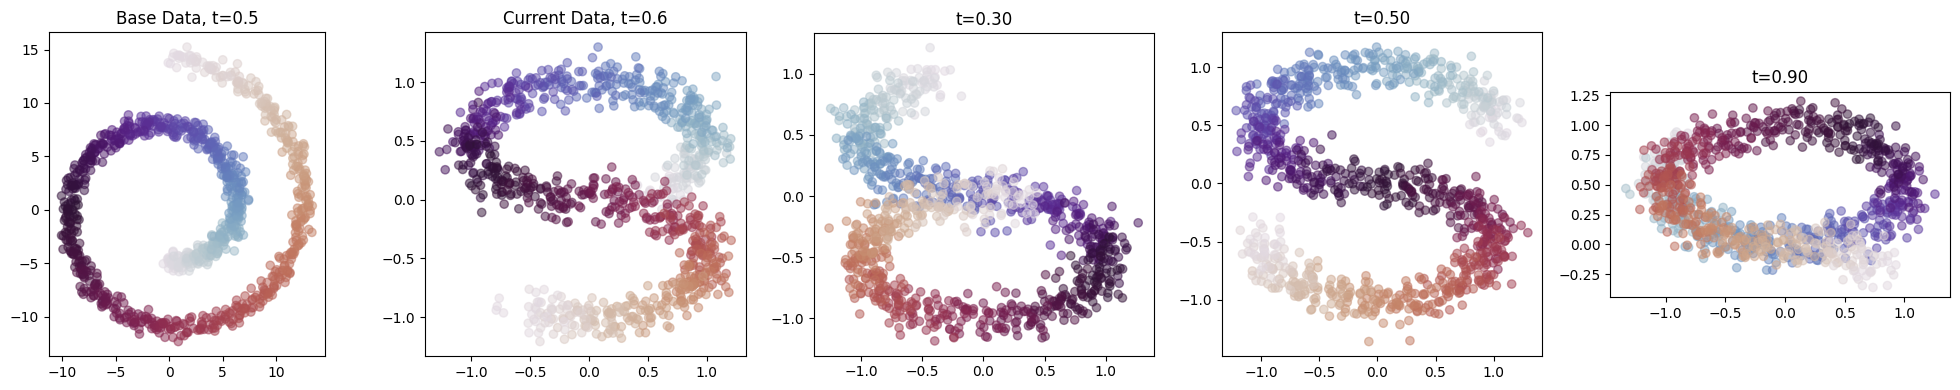

In [3]:
# Transform the base data and plot representative transform values.
base_data = dataset.transform_base(base_transform_config)
current_config: TransformConfig = get_transform_config(transform_params=current_transform_params, dataset=dataset)
if sim_params["dataset_type"] == "permuted_gaussian_clusters":
    visualization_param_name = sim_params["permuted_data_param"]
    visualization_values = get_data_param_sweep_values(dataset, visualization_param_name, sweep_len=3)
else:
    visualization_param_name = "t"
    visualization_values = [0.3, 0.5, 0.9]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes = axes.flatten()
plot_data(dataset, title=f"Base Data, {visualization_param_name}={base_transform_params[visualization_param_name]}", ax=axes[0], visualization_method=sim_params["visualization_method"], base_data=True)
dataset.transform_current(current_config)
plot_data(dataset, title=f"Current Data, {visualization_param_name}={current_transform_params[visualization_param_name]}", ax=axes[1], visualization_method=sim_params["visualization_method"], base_data=False)
for i, param_value in enumerate(visualization_values):
    current_config.set_param(visualization_param_name, param_value)
    dataset.transform_current(current_config)
    plot_data(dataset, title=f"{visualization_param_name}={param_value}", ax=axes[i+2], visualization_method=sim_params["visualization_method"])
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "data_visualization.png"))
plt.show()

## Test Alignment Metrics

In [ ]:
from manifold_repsim.metrics import AlignmentMetrics

# metric names
# metric_names = ['cka', 'cka_rbf', 'cka_rbf_local', 'mutual_knn', 'cknna', 'nn_rwka', 
#                 'ip_nn_rwka', 'rbf_rwka']
# metric_names = ['cka', 'cka_rbf', 'cka_rbf_local', 'mutual_knn', 'cknna']
# auc_metric_names = {'mutual_knn', 'cknna', 'rbf_rwka', 'cka_rbf'}
# smart_auc_metric_names = {'cka_rbf'}
# metric_names = ['cka', 'cka_rbf', 'cknna', 'cka_rbf_local', 'cka_rbf_quantile', 'mutual_knn',
#                 'cka_rbf_min_env', 'cka_rbf_min_to_cutoff', 'cka_rbf_cutoff_auc', 'cka_rbf_auc', 'cka_rbf_min', 'cka_rbf_convex_auc']
# metric_names = ['cka', 'cka_rbf', 'cka_rbf_local', 'cka_rbf_quantile', 'cknna', 'mutual_knn_dist', 'cka_rbf_cutoff_auc',
#                 'cka_rbf_min_env', 'cka_rbf_min_to_cutoff', 'cka_rbf_auc', 'cka_rbf_min', 'cka_rbf_convex_auc', 'cka_rbf_min_max_auc', 
#                 'softmax_rwka_auc', 'softmax_rwka', 'rbf_rwka_auc', 'rbf_rwka']
# metric_names = ['cka', 'cka_rbf', 'cka_rbf_local', 'cka_rbf_quantile', 'cknna', 'mutual_knn_dist',
#                 'cka_rbf_auc', 'cka_rbf_min','softmax_rwka_auc', 'softmax_rwka', 'softmax_rwka_min', 'rbf_rwka_auc', 'rbf_rwka', 'rbf_rwka_min_max_auc']
# metric_names = ['cka', 'cka_rbf_local', 'cka_rbf_quantile', 'mutual_knn_dist', 'cka_rbf_auc', 'cka_rbf_var_auc', 'softmax_rwka', 
#                 'softmax_rwka_auc', 'softmax_rwka_var_auc', 'rbf_rwka', 'rbf_rwka_auc', 'rbf_rwka_var_auc']
# metric_names = ['cka', 'mutual_knn_dist']
# metric_names = ['cka', 'cka_rbf', 'cka_rbf_local', 'mutual_knn_dist']
# metric_names = ['cka', 'mutual_knn_dist', 'cka_rbf', 'cka_rbf_local', 'cka_rbf_auc', 'cka_rbf_var_auc']
metric_names = ['cka', 'mutual_knn_dist', 'cka_rbf_auc', 'cka_rbf_var_auc', 'rbf_rwka_diffusion_time_auc', 'rbf_rwka_diffusion_time_var_auc', 'rbf_rwka_symmetric_auc', 'rbf_rwka_symmetric_var_auc']
# metric_names = ['cka', 'mutual_knn_dist', 'rbf_rwka', 'cka_rbf', 'cka_rbf_local', 'cka_rbf_auc', 'cka_rbf_var_auc', 'rbf_rwka_auc', 'rbf_rwka_var_auc']

metric_color_map = {
    # cka in blue shades
    'cka': 'dodgerblue',
    # green shades for mutual_knn variants
    'mutual_knn_dist': 'green',
    'mutual_knn': 'lightgreen',
    'mutual_knn_auc': 'darkgreen',
    'cknna': 'limegreen',
    # orange shades for cka_rbf variants
    'cka_rbf': 'orange',
    'cka_rbf_local': 'lightcoral',
    'cka_rbf_quantile': 'darkorange',
    'cka_rbf_cutoff_auc': 'goldenrod',
    'cka_rbf_var_auc': 'chocolate',
    'cka_rbf_auc': 'orangered',
    'cka_rbf_min': 'sandybrown',
    'cka_rbf_min_env': 'peru',
    'cka_rbf_min_to_cutoff': 'wheat',
    'cka_rbf_convex_auc': 'tomato',
    'cka_rbf_min_max_auc': 'salmon',
    # teal shades for rwka variants
    'rbf_rwka': 'teal',
    'rbf_rwka_local': 'lightseagreen',
    'rbf_rwka_auc': 'skyblue',
    'rbf_rwka_var_auc': 'mediumturquoise',
    'rbf_rwka_symmetric': 'seagreen',
    'rbf_rwka_symmetric_auc': 'mediumseagreen',
    'rbf_rwka_symmetric_var_auc': 'aquamarine',
    'rbf_rwka_diffusion_time': 'darkcyan',
    'rbf_rwka_diffusion_time_auc': 'deepskyblue',
    'rbf_rwka_diffusion_time_var_auc': 'cadetblue',
    'softmax_rwka': 'cyan',
    'softmax_rwka_auc': 'darkslategray',
    'softmax_rwka_var_auc': 'paleturquoise',
}


Running metric comparison across data parameter: t
Running metric comparison across data parameter: noise_scale


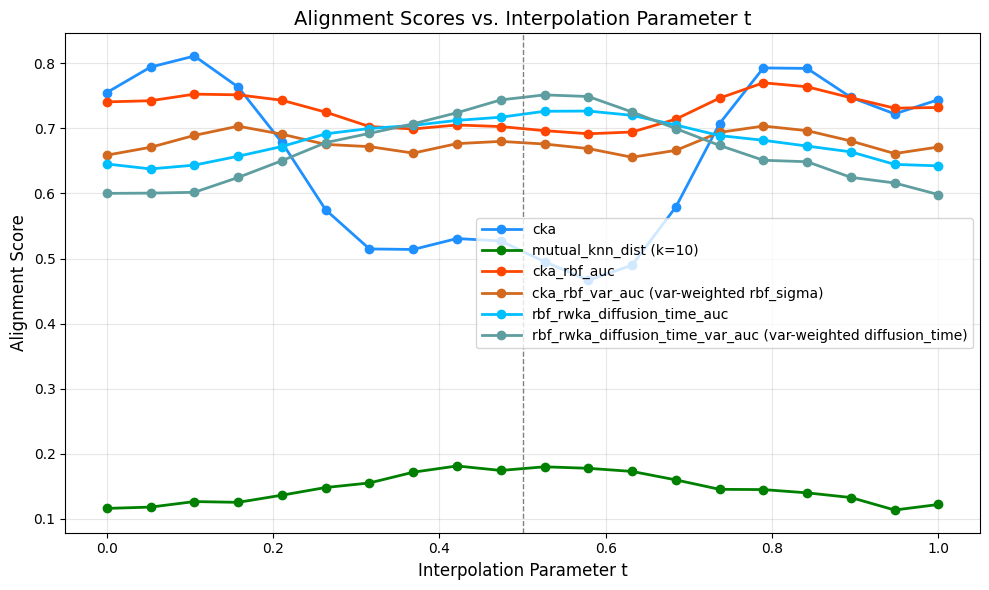

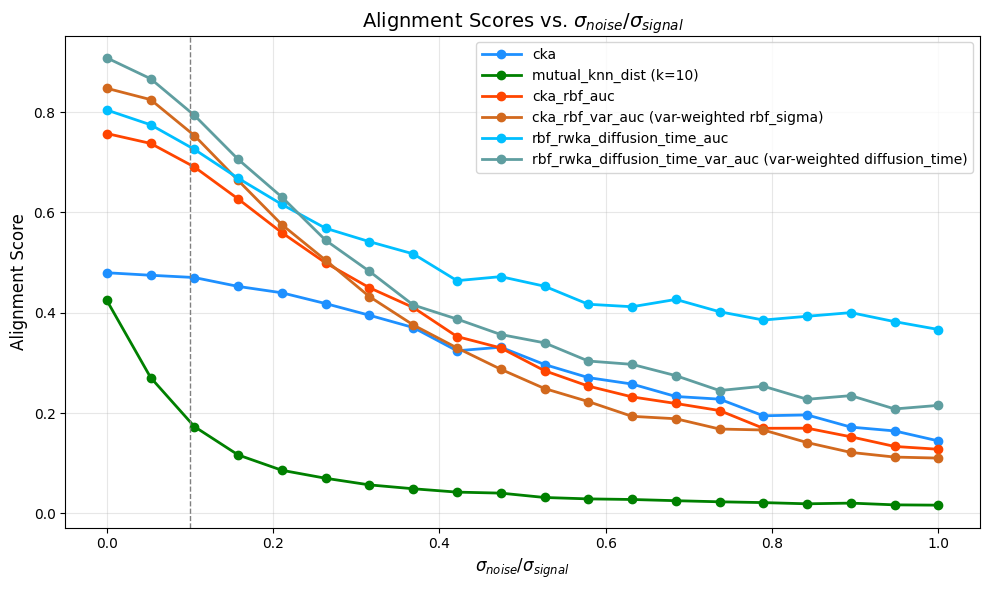

In [6]:
data_param_names = ["t", "noise_scale", "n_clusters", "n_rings", "n_permute", "cluster_mixing_probability"]
# run_name = 'cka_var_low_noise'
# run_name = 'cka_var_high_noise'
# run_name = 'rwka_var_low_noise'
run_name = 'rwka_var_high_noise'
# run_name = 'with_auc'
# run_name = 'cka_knn'
# run_name = 'cka_local'
# run_name = 'cka_local_high_noise'
run_path = os.path.join(figures_path, run_name)
os.makedirs(run_path, exist_ok=True)
for data_param_name in data_param_names:
    if data_param_name in base_transform_config.get_param_set():
        print(f"Running metric comparison across data parameter: {data_param_name}")
        run_metric_comparison_across_data_param(
            dataset=dataset,
            current_transform_params=current_transform_params,
            data_param_name=data_param_name,
            metric_names=metric_names,
            sim_params=sim_params,
            figures_path=run_path,
            metric_color_map=metric_color_map,
        )

### Interpolation Sweep

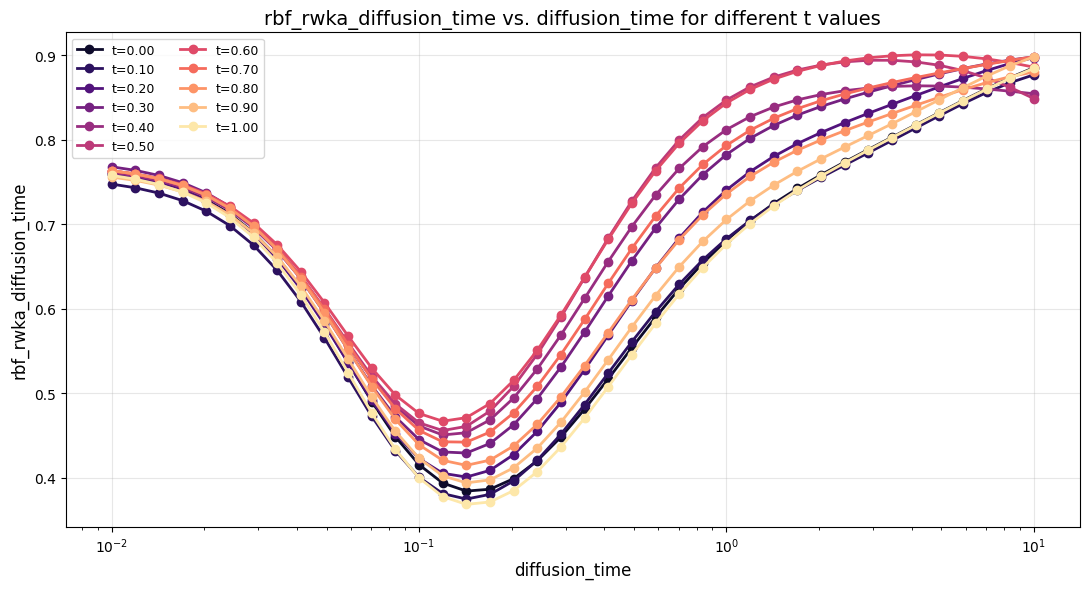

In [5]:
# Configurable metric comparison grid
# metric_name = "rbf_rwka_diffusion_time"
metric_name = "rbf_rwka_symmetric"
# metric_name = "cka_rbf"
if sim_params["dataset_type"] == "permuted_gaussian_clusters":
    data_param_name = sim_params["permuted_data_param"]
    data_param_values = get_data_param_sweep_values(dataset, data_param_name, sim_params["data_param_sweep_len"])
else:
    data_param_name = "t"
    data_param_values = np.linspace(0.0, 1.0, 11)
metric_sweep_len = sim_params["metric_param_sweep_len"]  # number of points in the hyperparameter sweep for the metric
plot_kind = "line"  # "line" or "heatmap"
logscale = True  # Whether to use logscale for the hyperparameter axis in the line plot

current_config: TransformConfig = get_transform_config(transform_params=current_transform_params, dataset=dataset)

# compute metric values
metric_param_name, data_param_values, metric_sweep_values, score_grid, inf_scores = run_param_sweep(
    metric_name=metric_name,
    dataset=dataset,
    base_transform_config=base_transform_config,
    transform_config=current_config,
    data_param_name=data_param_name,
    data_param_values=data_param_values,
    metric_sweep_len=metric_sweep_len, 
    metric_sweep_values=None, 
    metric_sweep_range=sim_params["metric_sweep_ranges"].get(metric_name),
    logscale=logscale,
)

# plot results
fig, ax = plot_param_sweep(
    metric_name=metric_name, 
    plot_kind=plot_kind, 
    metric_param_name=metric_param_name,
    metric_param_values=metric_sweep_values,
    data_param_name=data_param_name,
    data_param_values=data_param_values, 
    score_grid=score_grid, 
    inf_scores=inf_scores,
    sim_params=sim_params,
    save_path=figures_path, 
    logscale=logscale
)

### Dimension Sweep

In [7]:
if sim_params["dataset_type"] == "s_curve":
    print("Skipping metric comparison grid for s_curve dataset since dim=2 is fixed for it.")
else:
    # Configurable metric comparison grid
    # metric_name = "rbf_rwka_diffusion_time"
    metric_name = "rbf_rwka_symmetric"
    metric_sweep_len = sim_params["metric_param_sweep_len"]  # number of points in the hyperparameter sweep for the metric
    data_param_name = "dim"
    data_param_values = [2, 3, 5, 10, 15, 20, 30, 50, 75, 100]
    plot_kind = "line"  # "line" or "heatmap"
    logscale = True  # Whether to use logscale for the hyperparameter axis in the line plot

    current_config: TransformConfig = get_transform_config(transform_params=current_transform_params, dataset=dataset)

    # compute metric values
    metric_param_name, data_param_values, metric_sweep_values, score_grid, inf_scores = run_param_sweep(
        metric_name=metric_name,
        dataset=dataset,
        base_transform_config=base_transform_config,
        transform_config=current_config,
        data_param_name=data_param_name,
        data_param_values=data_param_values,
        metric_sweep_len=metric_sweep_len, 
        metric_sweep_values=None, 
        metric_sweep_range=sim_params["metric_sweep_ranges"].get(metric_name),
        logscale=logscale,
    )

    # plot results
    fig, ax = plot_param_sweep(
        metric_name=metric_name, 
        plot_kind=plot_kind, 
        metric_param_name=metric_param_name,
        metric_param_values=metric_sweep_values,
        data_param_name=data_param_name,
        data_param_values=data_param_values, 
        score_grid=score_grid, 
        inf_scores=inf_scores,
        sim_params=sim_params,
        save_path=figures_path, 
        logscale=logscale
    )


Skipping metric comparison grid for s_curve dataset since dim=2 is fixed for it.


### Noise Sweep

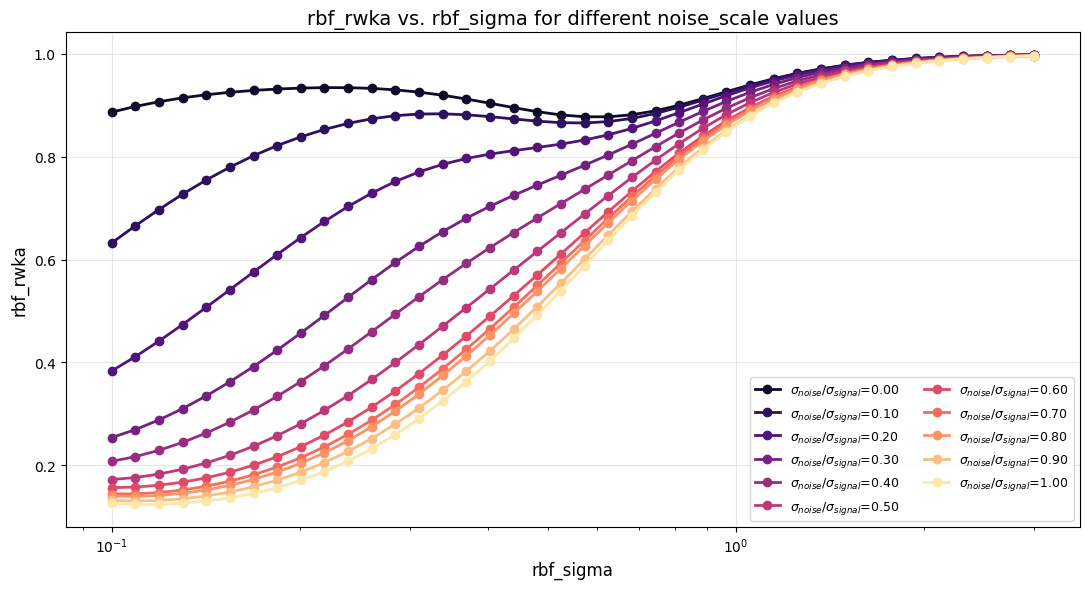

In [8]:
try:
    # Configurable metric comparison grid
    metric_name = "rbf_rwka_symmetric"
    data_param_name = "noise_scale"
    data_param_values = np.linspace(0.0, 1.0, 11)
    metric_sweep_len = sim_params["metric_param_sweep_len"]  # number of points in the hyperparameter sweep for the metric
    plot_kind = "line"  # "line" or "heatmap"
    logscale = True  # Whether to use logscale for the hyperparameter axis in the line plot

    current_config: TransformConfig = get_transform_config(transform_params=current_transform_params, dataset=dataset)

    # compute metric values
    metric_param_name, data_param_values, metric_sweep_values, score_grid, inf_scores = run_param_sweep(
        metric_name=metric_name,
        dataset=dataset,
        base_transform_config=base_transform_config,
        transform_config=current_config,
        data_param_name=data_param_name,
        data_param_values=data_param_values,
        metric_sweep_len=metric_sweep_len, 
        metric_sweep_values=None, 
        metric_sweep_range=sim_params["metric_sweep_ranges"].get(metric_name),
        logscale=logscale,
    )

    # plot results
    fig, ax = plot_param_sweep(
        metric_name=metric_name, 
        plot_kind=plot_kind, 
        metric_param_name=metric_param_name,
        metric_param_values=metric_sweep_values,
        data_param_name=data_param_name,
        data_param_values=data_param_values, 
        score_grid=score_grid, 
        inf_scores=inf_scores,
        sim_params=sim_params,
        save_path=figures_path, 
        logscale=logscale
    )
except ValueError as e:
    print(f"Error creating plot: {e}")

n_rings or n_clusters parameter sweep is not applicable for dataset type s_curve. Skipping this plot.


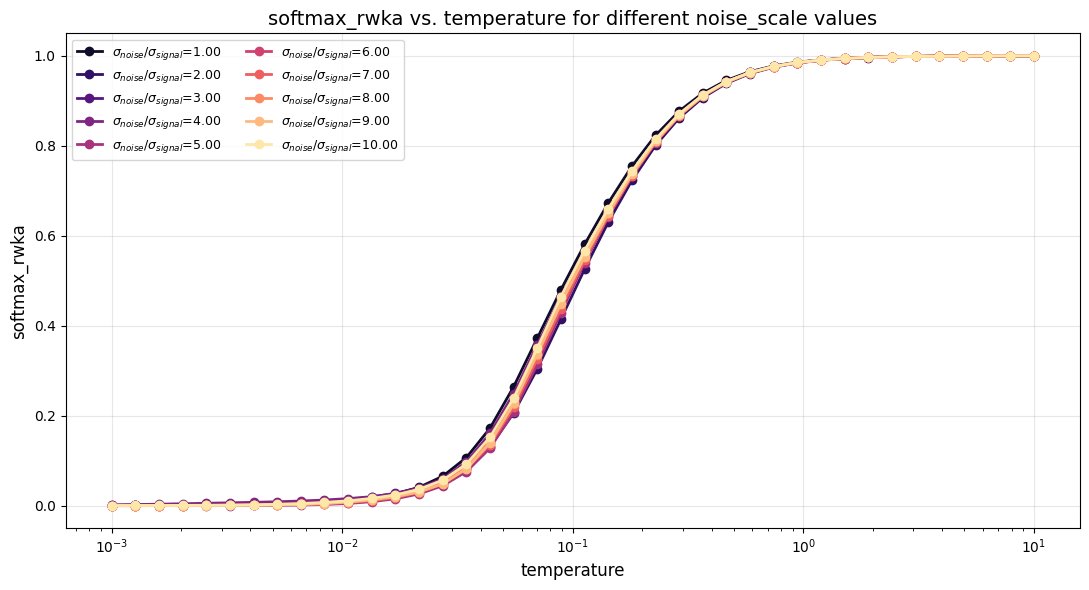

In [9]:
if sim_params["dataset_type"] == "gaussian_cluster":
    data_param_name = "n_clusters"
elif sim_params["dataset_type"] == "rings":
    data_param_name = "n_rings"
elif sim_params["dataset_type"] == "permuted_gaussian_clusters":
    data_param_name = sim_params["permuted_data_param"]
else:
    print(f"n_rings or n_clusters parameter sweep is not applicable for dataset type {sim_params['dataset_type']}. Skipping this plot.")
try:
    # Configurable metric comparison grid
    metric_name = "rbf_rwka_symmetric"
    data_param_values = (get_data_param_sweep_values(dataset, data_param_name, sim_params["data_param_sweep_len"]) if sim_params["dataset_type"] == "permuted_gaussian_clusters" else [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    metric_sweep_len = sim_params["metric_param_sweep_len"]  # number of points in the hyperparameter sweep for the metric
    plot_kind = "line"  # "line" or "heatmap"
    logscale = True  # Whether to use logscale for the hyperparameter axis in the line plot

    current_config: TransformConfig = get_transform_config(transform_params=current_transform_params, dataset=dataset)
    
    # compute metric values
    metric_param_name, data_param_values, metric_sweep_values, score_grid, inf_scores = run_param_sweep(
        metric_name=metric_name,
        dataset=dataset,
        base_transform_config=base_transform_config,
        transform_config=current_config,
        data_param_name=data_param_name,
        data_param_values=data_param_values,
        metric_sweep_len=metric_sweep_len, 
        metric_sweep_values=None, 
        metric_sweep_range=sim_params["metric_sweep_ranges"].get(metric_name),
        logscale=logscale,
    )

    # plot results
    fig, ax = plot_param_sweep(
        metric_name=metric_name, 
        plot_kind=plot_kind, 
        metric_param_name=metric_param_name,
        metric_param_values=metric_sweep_values,
        data_param_name=data_param_name,
        data_param_values=data_param_values, 
        score_grid=score_grid, 
        inf_scores=inf_scores,
        sim_params=sim_params,
        save_path=figures_path, 
        logscale=logscale
    )
except ValueError as e:
    print(f"Error creating plot: {e}")